**【课程】**：[100天风控专家](https://bzavt.xetlk.com/s/2Y1t7x)
**【店铺】**：[东哥讲风控](https://app7hmmvkwr2019.h5.xiaoeknow.com)
**【作者】**：东哥起飞

In [69]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [70]:
# 版本
import sklearn as sk
print('pandas: %s' %pd.__version__)
print('numpy: %s' %np.__version__)
print('sklearn: %s' %sk.__version__)

pandas: 2.0.0
numpy: 1.23.5
sklearn: 1.3.2


## 1. 导入数据

In [71]:
# 1. 导入数据
df = pd.read_excel('data_sample.xlsx')
print(f"数据形状: {df.shape}")

# 2. 等级编码
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
df['repayment_ability_rank'] = df['repayment_ability_rank'].map(grade_mapping)
df['dev_stability_grade'] = df['dev_stability_grade'].map(grade_mapping)

# 3. 划分特征和目标
feature_names = [col for col in df.columns if col != 'y']
X = df[feature_names]
y = df['y']

print(f"特征矩阵: {X.shape}")
print(f"目标变量: {y.shape}")
print(f"特征列表: {feature_names}")

数据形状: (50000, 7)
特征矩阵: (50000, 6)
目标变量: (50000,)
特征列表: ['ovd_order_days_6m_grade', 'ovd_order_cnt_6m_grade', 'repayment_ability_rank', 'dev_stability_grade', 'have_fang_prob_grade', 'positive_biz_cnt_1y_grade']


## 2. WOE分箱和IV值计算

In [72]:
# 数据预处理和分箱
def create_woe_bins(df, feature, target, max_bins=5):
    """创建WOE分箱"""
    # 等频分箱
    df_temp = df[[feature, target]].copy()
    df_temp['bin'], bins = pd.qcut(df_temp[feature], q=max_bins, duplicates='drop', retbins=True)
    
    # 计算WOE
    bin_stats = df_temp.groupby('bin', observed=False).agg(
        count=(target, 'count'),
        good=(target, lambda x: (x == 0).sum()),
        bad=(target, lambda x: (x == 1).sum())
    ).reset_index()
    
    bin_stats['good_rate'] = bin_stats['good'] / bin_stats['count']
    bin_stats['bad_rate'] = bin_stats['bad'] / bin_stats['count']
    bin_stats['dist_good'] = bin_stats['good'] / bin_stats['good'].sum()
    bin_stats['dist_bad'] = bin_stats['bad'] / bin_stats['bad'].sum()
    bin_stats['woe'] = np.log(bin_stats['dist_good'] / bin_stats['dist_bad'])
    bin_stats['iv'] = (bin_stats['dist_good'] - bin_stats['dist_bad']) * bin_stats['woe']
    
    bin_stats['variable'] = feature
    bin_stats = bin_stats.rename(columns={'bin': 'bin'})
    
    return bin_stats[['variable', 'bin', 'woe', 'iv']]

# 对所有特征进行分箱
# features = ['age', 'income', 'credit_amount', 'employment_years', 'existing_loans', 'credit_card_usage']
bins_list = []

for feature in feature_names:
    feature_bins = create_woe_bins(df, feature, 'y')
    bins_list.append(feature_bins)

# 合并所有分箱结果
all_bins = pd.concat(bins_list, ignore_index=True)
print("WOE分箱结果:")
print(all_bins.head(10))

# 计算总IV值
total_iv = all_bins.groupby('variable')['iv'].sum()
print("\n各特征IV值:")
print(total_iv.sort_values(ascending=False))

WOE分箱结果:
                    variable           bin       woe        iv
0    ovd_order_days_6m_grade  (0.999, 5.0]  0.000000  0.000000
1     ovd_order_cnt_6m_grade  (0.999, 2.0]  0.478978  0.165865
2     ovd_order_cnt_6m_grade    (2.0, 5.0] -1.577516  0.546276
3     repayment_ability_rank  (0.999, 2.0]  0.238055  0.031365
4     repayment_ability_rank    (2.0, 4.0] -0.299007  0.039396
5        dev_stability_grade  (0.999, 2.0]  0.202159  0.019358
6        dev_stability_grade    (2.0, 3.0] -0.018847  0.000112
7        dev_stability_grade    (3.0, 4.0] -0.434668  0.039043
8       have_fang_prob_grade  (0.999, 2.0]  0.000000  0.000000
9  positive_biz_cnt_1y_grade  (0.999, 4.0] -0.678139  0.155083

各特征IV值:
variable
ovd_order_cnt_6m_grade       0.712141
positive_biz_cnt_1y_grade    0.321809
repayment_ability_rank       0.070761
dev_stability_grade          0.058512
have_fang_prob_grade         0.000000
ovd_order_days_6m_grade      0.000000
Name: iv, dtype: float64


## 3. 特征编码和模型训练

In [73]:
# 将原始特征转换为WOE值
def feature_to_woe(df, bins_df):
    """将特征值转换为WOE值"""
    df_woe = df.copy()
    
    for feature in bins_df['variable'].unique():
        feature_bins = bins_df[bins_df['variable'] == feature]
        
        # 创建映射函数
        woe_map = {}
        for _, row in feature_bins.iterrows():
            if isinstance(row['bin'], pd.Interval):
                woe_map[row['bin']] = row['woe']
        
        # 应用WOE转换
        def map_to_woe(x):
            for interval, woe_value in woe_map.items():
                if x in interval:
                    return woe_value
            return 0  # 默认值
        
        df_woe[f'{feature}_woe'] = df_woe[feature].apply(map_to_woe)
    
    return df_woe

# IV>0
feature_names_iv = total_iv[total_iv > 0].index.tolist()
all_bins_new = all_bins[all_bins['variable'].isin(feature_names_iv)]

# 应用WOE转换
df_woe = feature_to_woe(df, all_bins_new)

# 准备建模数据
woe_features = [f'{feat}_woe' for feat in feature_names_iv]
X = df_woe[woe_features]
y = df_woe['y']

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 训练逻辑回归模型
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# 模型评估
y_pred_test_proba  = model.predict_proba(X_test)[:, 1]
y_pred_train_proba = model.predict_proba(X_train)[:, 1]

auc_test_score  = roc_auc_score(y_test, y_pred_test_proba)
auc_train_score = roc_auc_score(y_train, y_pred_train_proba)

print(f"模型AUC: {auc_test_score:.4f}")
print(f"模型系数: {model.coef_[0]}")
print(f"模型截距: {model.intercept_[0]:.4f}")

模型AUC: 0.7509
模型系数: [-0.79334144 -0.89852052 -0.75263205 -0.61170019]
模型截距: -2.1936


## 4. 评分卡生成函数

In [74]:
def cal_card(model, bins, rumo_col, base_score, odds_score, odds):
    """
    生成评分卡
    
    参数:
    model: 训练好的逻辑回归模型
    bins: 分箱DataFrame列表
    rumo_col: 特征列名
    base_score: 基础分
    odds_score: 指定odds对应的分数
    odds: 指定的odds值
    """
    card = {}
    
    # 计算A和B参数
    b = odds_score / np.log(2)
    a = base_score + b * np.log(odds)
    basepoints = a - b * model.intercept_[0]
    
    # 获取非零系数
    coef_df = pd.Series(model.coef_[0], index=np.array(rumo_col)).loc[lambda x: x != 0]
    
    # 合并所有分箱
    bins_combined = pd.concat(bins, ignore_index=True)
    
    # 创建基础分DataFrame
    card_df = pd.DataFrame({'variable': ["basepoints"], 'bin': [np.nan], 'points': [round(basepoints, 4)]})
    
    # 为每个特征计算分数
    for i in coef_df.index:
        feature_name = i.replace('_woe', '')  # 去掉_woe后缀
        feature_points = bins_combined.loc[bins_combined['variable'] == feature_name, ['variable', 'bin', 'woe']].assign(
            points=lambda x: round(-b * x['woe'] * coef_df[i], 4)
        )[["variable", "bin", "points"]]
        card_df = pd.concat([card_df, feature_points], ignore_index=True)
    
    return card_df,a,b

# 生成评分卡
rumo_col = woe_features  # 特征列名
base_score = 600  # 基础分
odds_score = 50   # PDO (Points to Double the Odds)
odds = 1/19       # 基准odds

# 调用评分卡生成函数
score_card,a,b = cal_card(model, bins_list, rumo_col, base_score, odds_score, odds)

print("生成的评分卡:")
print(score_card)
print('a:{0},b:{1}',(a,b))

生成的评分卡:
                     variable           bin    points
0                  basepoints           NaN  545.8351
1         dev_stability_grade  (0.999, 2.0]   11.5690
2         dev_stability_grade    (2.0, 3.0]   -1.0785
3         dev_stability_grade    (3.0, 4.0]  -24.8750
4      ovd_order_cnt_6m_grade  (0.999, 2.0]   31.0447
5      ovd_order_cnt_6m_grade    (2.0, 5.0] -102.2460
6   positive_biz_cnt_1y_grade  (0.999, 4.0]  -36.8168
7   positive_biz_cnt_1y_grade    (4.0, 6.0]   -9.4829
8   positive_biz_cnt_1y_grade    (6.0, 9.0]   15.9454
9   positive_biz_cnt_1y_grade   (9.0, 10.0]   40.6741
10     repayment_ability_rank  (0.999, 2.0]   10.5041
11     repayment_ability_rank    (2.0, 4.0]  -13.1936
a:{0},b:{1} (387.6036243278207, 72.13475204444818)


## 5. 应用评分卡和结果分析

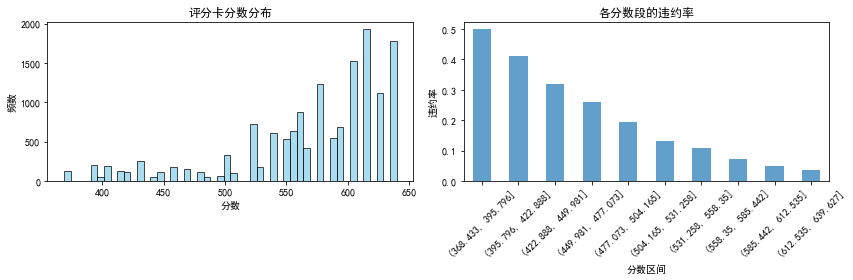


=== 评分卡统计信息 ===
分数范围: [368.7, 639.6]
平均分数: 569.6
中位数分数: 589.5

=== 评分卡统计信息 ===
分数范围: [368.7, 639.6]
平均分数: 569.8
中位数分数: 589.5

=== 详细评分卡 ===
basepoints: 545.8351分
dev_stability_grade (0.999, 2.0]: 11.569分
dev_stability_grade (2.0, 3.0]: -1.0785分
dev_stability_grade (3.0, 4.0]: -24.875分
ovd_order_cnt_6m_grade (0.999, 2.0]: 31.0447分
ovd_order_cnt_6m_grade (2.0, 5.0]: -102.246分
positive_biz_cnt_1y_grade (0.999, 4.0]: -36.8168分
positive_biz_cnt_1y_grade (4.0, 6.0]: -9.4829分
positive_biz_cnt_1y_grade (6.0, 9.0]: 15.9454分
positive_biz_cnt_1y_grade (9.0, 10.0]: 40.6741分
repayment_ability_rank (0.999, 2.0]: 10.5041分
repayment_ability_rank (2.0, 4.0]: -13.1936分


In [75]:
# 计算每个样本的评分卡得分
def calculate_score(row, score_card_df):
    """计算单个样本的评分卡得分"""
    total_score = score_card_df[score_card_df['variable'] == 'basepoints']['points'].iloc[0]
    
    for _, card_row in score_card_df[score_card_df['variable'] != 'basepoints'].iterrows():
        feature = card_row['variable']
        bin_interval = card_row['bin']
        points = card_row['points']
        
        if isinstance(bin_interval, pd.Interval):
            if row[feature] in bin_interval:
                total_score += points
        else:
            # 处理特殊情况
            pass
            
    return total_score

# 由于样本级别的评分计算较复杂，我们使用模型概率来近似计算分数
def probability_to_score(prob, base_score, odds_score, odds):
    """将概率转换为分数"""
    b = odds_score / np.log(2)
    a = base_score + b * np.log(odds)
    score = a - b * np.log(prob / (1 - prob + 1e-8))
    return score

# 计算测试集的分数
test_scores  = probability_to_score(y_pred_test_proba, base_score, odds_score, odds)
train_scores = probability_to_score(y_pred_train_proba, base_score, odds_score, odds)

# 分析分数分布
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(test_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('评分卡分数分布')
plt.xlabel('分数')
plt.ylabel('频数')

plt.subplot(1, 2, 2)
# 按分数分组计算违约率
score_bins = pd.cut(test_scores, bins=10)
default_rates = pd.DataFrame({
    'score_bin': score_bins,
    'default': y_test.values
}).groupby('score_bin')['default'].mean()

default_rates.plot(kind='bar', alpha=0.7)
plt.title('各分数段的违约率')
plt.xlabel('分数区间')
plt.ylabel('违约率')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 输出评分卡统计信息
print("\n=== 评分卡统计信息 ===")
print(f"分数范围: [{test_scores.min():.1f}, {test_scores.max():.1f}]")
print(f"平均分数: {test_scores.mean():.1f}")
print(f"中位数分数: {np.median(test_scores):.1f}")

# 输出评分卡统计信息
print("\n=== 评分卡统计信息 ===")
print(f"分数范围: [{train_scores.min():.1f}, {train_scores.max():.1f}]")
print(f"平均分数: {train_scores.mean():.1f}")
print(f"中位数分数: {np.median(train_scores):.1f}")

# 显示详细的评分卡
print("\n=== 详细评分卡 ===")
for _, row in score_card.iterrows():
    if pd.isna(row['bin']):
        print(f"{row['variable']}: {row['points']}分")
    else:
        print(f"{row['variable']} {row['bin']}: {row['points']}分")

## 6. CSI计算

In [76]:
# ============================================================
# 第一步：构建评分卡查询表（特征 → 分箱区间 → 分数）
# ============================================================

# 从 score_card 中提取各特征各分箱的分数映射
scorecard_map = {}  # {feature_name: [(interval, points), ...]}
for _, row in score_card.iterrows():
    if pd.notna(row['bin']) and row['variable'] != 'basepoints':
        feat = row['variable']
        if feat not in scorecard_map:
            scorecard_map[feat] = []
        scorecard_map[feat].append((row['bin'], row['points']))


def get_score_points(feature_name, bin_interval, scorecard_map):
    """
    根据特征名和分箱区间，从评分卡中查找对应的分数
    """
    if feature_name not in scorecard_map:
        return 0.0
    for interval, points in scorecard_map[feature_name]:
        if interval == bin_interval:
            return points
    return 0.0

# ============================================================
# 第二步：CSI 计算
#
#   CSI_j = Σ_i (Actual%_ij - Expected%_ij) × Points_ij
#
#   其中：
#   - Expected% = 训练集在该特征第i箱的占比
#   - Actual%   = 测试集在该特征第i箱的占比
#   - Points    = 评分卡中该箱对应的分数
#
#   含义：该特征分布偏移导致评分平均偏移了多少分
# ============================================================

def calculate_csi(train_series, test_series, feature_name, scorecard_map, bins=10):
    """
    计算单个特征的 CSI

    CSI = Σ (Actual% - Expected%) × Points

    参数:
    train_series:    训练集数据（期望分布 Expected）
    test_series:     测试集数据（实际分布 Actual）
    feature_name:    特征名（用于查评分卡分数）
    scorecard_map:   评分卡分数映射
    bins:            分箱数

    返回:
    csi_value:       CSI 值（分数偏移量）
    csi_detail:      各分箱明细
    """
    # 基于训练集等频分箱，获取分箱边界
    train_binned, bin_edges = pd.qcut(
        train_series, q=bins, duplicates='drop', retbins=True
    )

    # 训练集各分箱占比（期望分布）
    expected_dist = train_binned.value_counts(normalize=True).sort_index()

    # 用相同边界切测试集
    test_binned = pd.cut(test_series, bins=bin_edges)
    actual_dist = test_binned.value_counts(normalize=True).sort_index()

    # 对齐分箱
    all_bins = expected_dist.index.union(actual_dist.index)
    expected = expected_dist.reindex(all_bins, fill_value=0)
    actual = actual_dist.reindex(all_bins, fill_value=0)

    # 从评分卡中查找每个分箱的分数
    points_list = []
    for bin_interval in all_bins:
        points = get_score_points(feature_name, bin_interval, scorecard_map)
        points_list.append(points)

    # CSI = Σ (Actual% - Expected%) × Points
    csi_contribution = (actual.values - expected.values) * np.array(points_list)
    csi_value = csi_contribution.sum()

    # 明细
    csi_detail = pd.DataFrame({
        'feature': feature_name,
        'bin': [str(b) for b in all_bins],
        'expected_pct': expected.values,
        'actual_pct': actual.values,
        'dist_shift': (actual - expected).values,
        'score_points': points_list,
        'csi_contrib': csi_contribution
    })

    return csi_value, csi_detail


# ============================================================
# 第三步：计算所有特征的 CSI
# ============================================================

# 训练/测试集对应的原始特征
X_train_orig = df.loc[X_train.index, feature_names_iv]
X_test_orig  = df.loc[X_test.index, feature_names_iv]

feature_csi_results = []
feature_csi_details = {}

for feat in feature_names_iv:
    csi_val, detail = calculate_csi(
        X_train_orig[feat], X_test_orig[feat], feat, scorecard_map, bins=10
    )
    feature_csi_results.append({'feature': feat, 'csi': csi_val})
    feature_csi_details[feat] = detail

csi_summary = pd.DataFrame(feature_csi_results).sort_values('csi', key=abs, ascending=False)

print("=" * 70)
print("CSI (Characteristic Stability Index) 分析结果")
print("CSI = Σ (Actual% - Expected%) × Scorecard_Points")
print("单位：分数偏移量（正数=测试集平均分偏高，负数=偏低）")
print("=" * 70)
print(csi_summary.to_string(index=False))

CSI (Characteristic Stability Index) 分析结果
CSI = Σ (Actual% - Expected%) × Scorecard_Points
单位：分数偏移量（正数=测试集平均分偏高，负数=偏低）
                  feature        csi
   ovd_order_cnt_6m_grade -27.182739
      dev_stability_grade  -6.580876
   repayment_ability_rank  -6.388594
positive_biz_cnt_1y_grade   0.141144


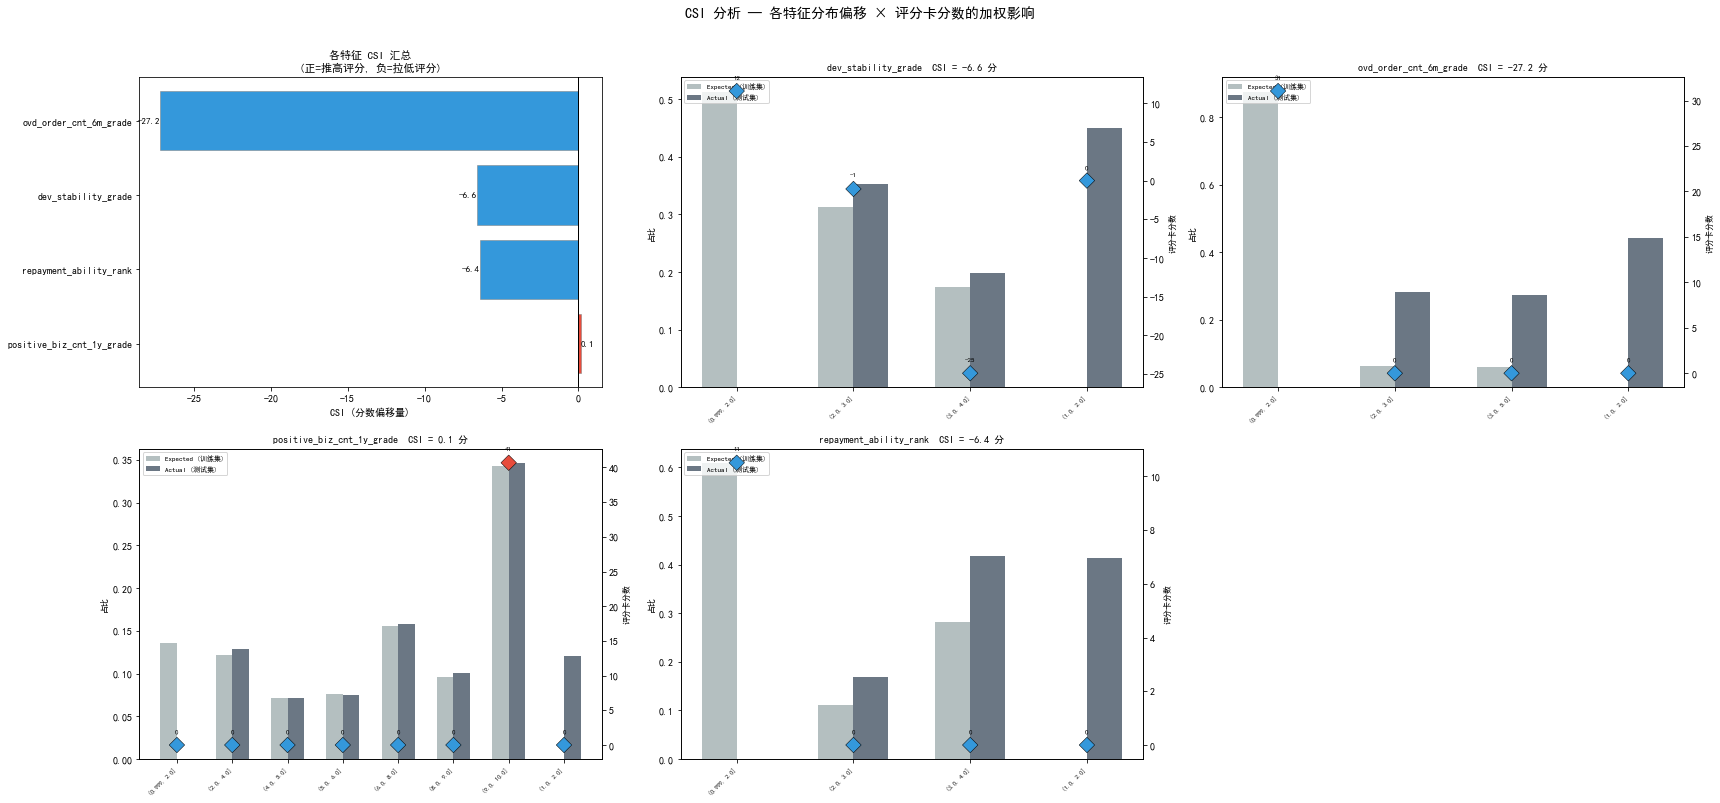

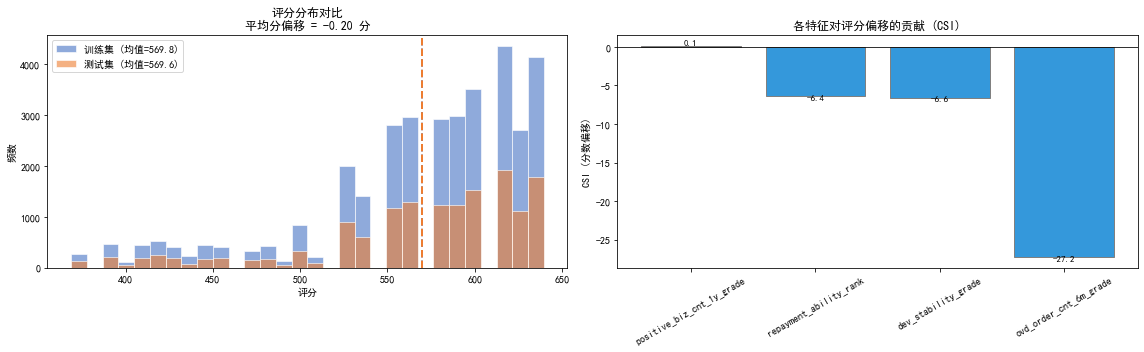


模型稳定性综合报告
  AUC                      : 0.6866
  训练集平均分              : 569.84
  测试集平均分              : 569.64
  平均分偏移 (Actual - Exp) : -0.20
  总 CSI (Σ各特征)          : -40.01
----------------------------------------------------------------------
各特征 CSI (分数偏移量)：
  ovd_order_cnt_6m_grade    CSI =   -27.18 分  (↓ 拉低评分)
  dev_stability_grade       CSI =    -6.58 分  (↓ 拉低评分)
  repayment_ability_rank    CSI =    -6.39 分  (↓ 拉低评分)
  positive_biz_cnt_1y_grade CSI =     0.14 分  (↑ 推高评分)


In [77]:
# ============================================================
# 第四步：可视化
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(24, 11))
axes = axes.flatten()

# 颜色函数：正贡献=红色（推高分数），负贡献=蓝色（拉低分数）
def contrib_color(val):
    return '#E74C3C' if val > 0 else '#3498DB'

# --- 子图0：CSI 汇总柱状图 ---
ax = axes[0]
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in csi_summary['csi']]
bars = ax.barh(csi_summary['feature'], csi_summary['csi'], color=colors, edgecolor='grey', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('CSI (分数偏移量)', fontsize=10)
ax.set_title('各特征 CSI 汇总\n(正=推高评分, 负=拉低评分)', fontsize=11, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, csi_summary['csi']):
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right', fontweight='bold')

# --- 子图1-6：各特征的分布偏移 × 分数明细 ---
for idx, feat in enumerate(feature_names_iv):
    ax = axes[idx + 1]
    detail = feature_csi_details[feat]
    x_labels = detail['bin']
    x = range(len(x_labels))

    # 分布对比
    ax2 = ax.twinx()
    width = 0.3
    ax.bar([i - width/2 for i in x], detail['expected_pct'],
           width, label='Expected (训练集)', alpha=0.7, color='#95A5A6')
    ax.bar([i + width/2 for i in x], detail['actual_pct'],
           width, label='Actual (测试集)', alpha=0.7, color='#2C3E50')

    # CSI贡献用散点标注
    colors_contrib = [contrib_color(v) for v in detail['csi_contrib']]
    ax2.scatter(x, detail['score_points'], s=120, c=colors_contrib,
                marker='D', zorder=5, edgecolors='black', linewidth=0.5)
    for i, (pt, contrib) in enumerate(zip(detail['score_points'], detail['csi_contrib'])):
        ax2.annotate(f'{pt:.0f}', (x[i], pt), textcoords="offset points",
                     xytext=(0, 12), ha='center', fontsize=7, fontweight='bold')

    csi_val = csi_summary[csi_summary['feature'] == feat]['csi'].values[0]
    ax.set_title(f'{feat}  CSI = {csi_val:.1f} 分', fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=6)
    ax.set_ylabel('占比', fontsize=8)
    ax2.set_ylabel('评分卡分数', fontsize=8)
    ax.legend(fontsize=7, loc='upper left')

# 隐藏多余子图
axes[5].set_visible(False)

plt.suptitle('CSI 分析 — 各特征分布偏移 × 评分卡分数的加权影响',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- 补充：评分分布对比 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
ax1.hist(train_scores, bins=30, alpha=0.6, label=f'训练集 (均值={train_scores.mean():.1f})',
         color='#4472C4', edgecolor='white')
ax1.hist(test_scores, bins=30, alpha=0.6, label=f'测试集 (均值={test_scores.mean():.1f})',
         color='#ED7D31', edgecolor='white')
ax1.axvline(train_scores.mean(), color='#4472C4', linestyle='--', linewidth=2)
ax1.axvline(test_scores.mean(), color='#ED7D31', linestyle='--', linewidth=2)
ax1.set_title(f'评分分布对比\n平均分偏移 = {test_scores.mean() - train_scores.mean():.2f} 分',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('评分')
ax1.set_ylabel('频数')
ax1.legend()

ax2 = axes[1]
# CSI 贡献瀑布图
contrib_sorted = csi_summary.sort_values('csi', ascending=False)
colors_wf = ['#E74C3C' if v > 0 else '#3498DB' for v in contrib_sorted['csi']]
ax2.bar(contrib_sorted['feature'], contrib_sorted['csi'], color=colors_wf, edgecolor='grey')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('各特征对评分偏移的贡献 (CSI)', fontsize=12, fontweight='bold')
ax2.set_ylabel('CSI (分数偏移)')
ax2.tick_params(axis='x', rotation=30)
for i, (feat, val) in enumerate(zip(contrib_sorted['feature'], contrib_sorted['csi'])):
    ax2.text(i, val + (0.1 if val >= 0 else -0.5), f'{val:.1f}',
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# 第七步：综合报告
# ============================================================
print("\n" + "=" * 70)
print("模型稳定性综合报告")
print("=" * 70)
print(f"  AUC                      : {auc_score:.4f}")
print(f"  训练集平均分              : {train_scores.mean():.2f}")
print(f"  测试集平均分              : {test_scores.mean():.2f}")
print(f"  平均分偏移 (Actual - Exp) : {test_scores.mean() - train_scores.mean():.2f}")
print(f"  总 CSI (Σ各特征)          : {csi_summary['csi'].sum():.2f}")
print("-" * 70)
print("各特征 CSI (分数偏移量)：")
for _, row in csi_summary.iterrows():
    direction = "↑ 推高评分" if row['csi'] > 0 else "↓ 拉低评分"
    print(f"  {row['feature']:<25s} CSI = {row['csi']:>8.2f} 分  ({direction})")

## At Last.好课推荐

更多风控好课👉[东哥讲风控](https://app7hmmvkwr2019.h5.xiaoeknow.com)

### 1）贷前策略实战项目（提高班）

贷前策略实战项目，4大真实贷前场景实战项目

内容详情介绍👉[《贷前策略实战项目（提高班）》](https://mp.weixin.qq.com/s/33nsHN3v_Zf9sPkr-yp_iA)，下单链接👉[点这里](https://bzavt.xetlk.com/s/4io33W)

### 2）pandas进阶宝典

Pandas数据分析的各种骚操作，东哥的原创笔记， 500页飞书图文笔记，近30万字，已经完全体。配套完整代码支持下载，永久访问权限。

内容详情介绍👉[《pandas进阶宝典》](https://mp.weixin.qq.com/s/9WbDFamcK2WywagdfN_f9Q)，包括5大核心图文，下单链接👉[点这里](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

以上如有不清楚也可加我微信：`Petery_1966` 咨询